In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joniarroba/noshowappointments")

print("Path to dataset files:", path)
import os

Using Colab cache for faster access to the 'noshowappointments' dataset.
Path to dataset files: /kaggle/input/noshowappointments


In [ ]:
# ==========================================
# HEALTHCARE & TELEMEDICINE EDA PROJECT
# ==========================================

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from scipy.stats import (
    boxcox,
    chi2_contingency,
    f_oneway,
    skew
)

In [ ]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(os.path.join(path, "KaggleV2-May-2016.csv"))
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [ ]:
print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)


DATASET SHAPE
(110527, 14)


In [ ]:
# ==========================================
# DATA UNDERSTANDING
# ==========================================

print("\nFIRST 5 RECORDS")
print(df.head())

print("\nDATA INFORMATION")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())



FIRST 5 RECORDS
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0          

In [ ]:
# ==========================================
# MISSING VALUES
# ==========================================

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================
# DUPLICATES
# ==========================================

print("\nDUPLICATE RECORDS")
print(df.duplicated().sum())


MISSING VALUES
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

DUPLICATE RECORDS
0


In [ ]:
# ==========================================
# DATETIME CONVERSION
# ==========================================

df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])


In [ ]:
# ==========================================
# FEATURE ENGINEERING
# WAITING TIME
# ==========================================

df['Waiting_Time'] = (
    df['AppointmentDay'] - df['ScheduledDay']
).dt.days


NUMBER OF AGE OUTLIERS
5


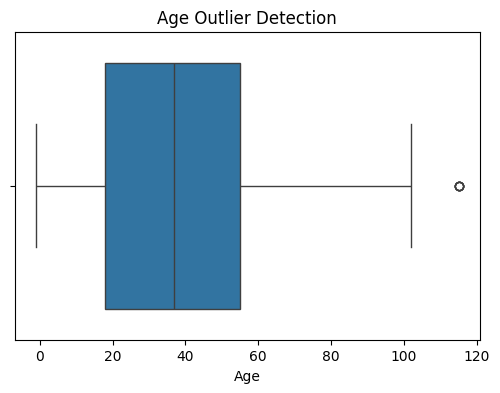

In [ ]:
# Remove negative waiting times

df['Waiting_Time'] = df['Waiting_Time'].clip(lower=0)

# ==========================================
# OUTLIER ANALYSIS (AGE)
# ==========================================

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Age'] < lower) |
    (df['Age'] > upper)
]

print("\nNUMBER OF AGE OUTLIERS")
print(len(outliers))

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Age Outlier Detection")
plt.show()


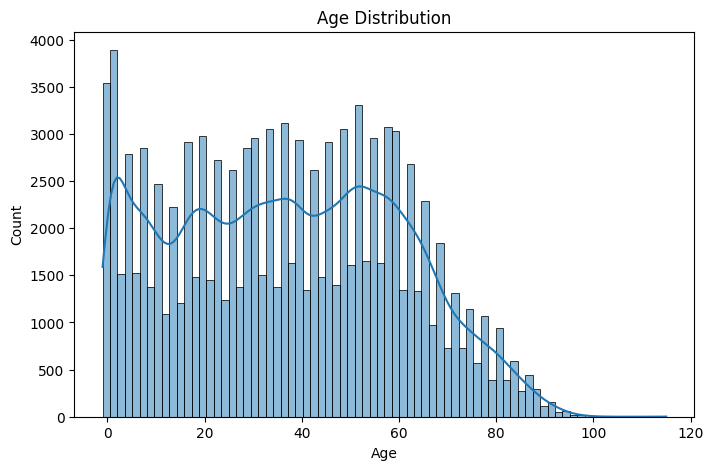


BOX COX LAMBDA
-0.2009130403716404


In [ ]:
# ==========================================
# DISTRIBUTION ANALYSIS
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# ==========================================
# LOG TRANSFORMATION
# ==========================================

# Ensure Waiting_Time is non-negative before transformation
df['Waiting_Time'] = df['Waiting_Time'].clip(lower=0)
df['Waiting_Log'] = np.log1p(df['Waiting_Time'])

# ==========================================
# BOX COX TRANSFORMATION
# ==========================================
df['Waiting_Boxcox'], lam = boxcox(
    df['Waiting_Time'] + 1
)
print("\nBOX COX LAMBDA")
print(lam)

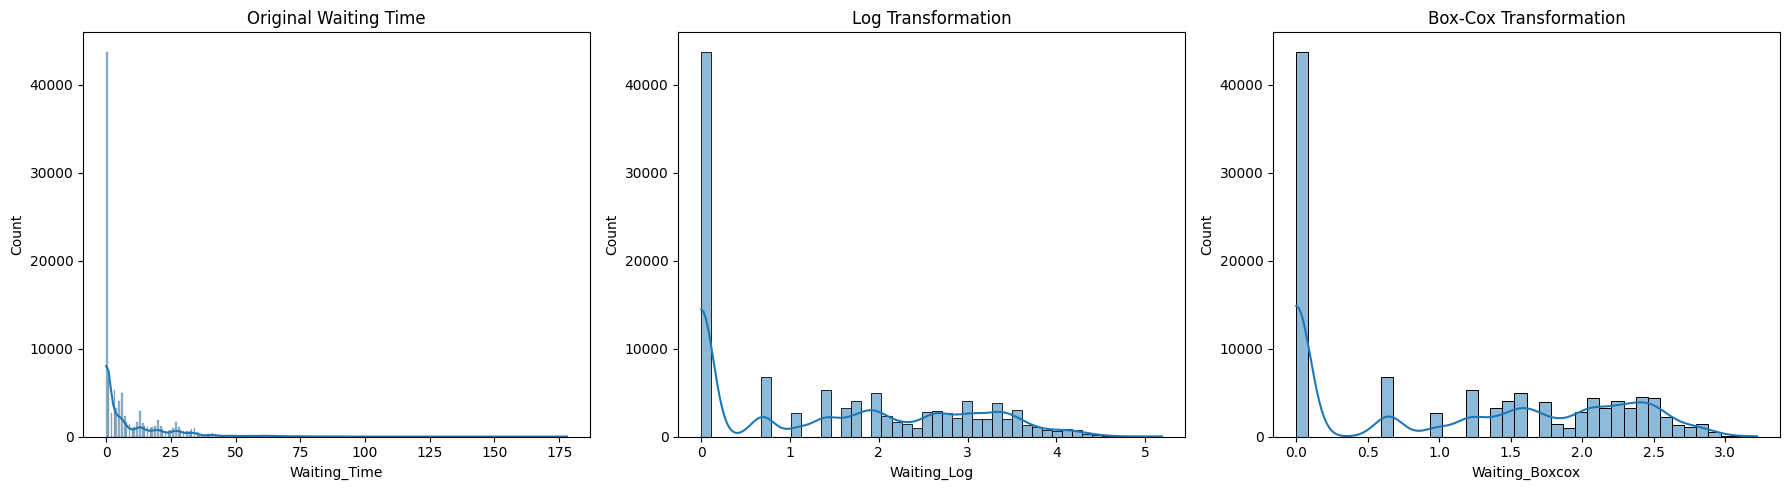

In [ ]:
# ==========================================
# TRANSFORMATION COMPARISON
# ==========================================

fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(
    df['Waiting_Time'],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Waiting Time")

sns.histplot(
    df['Waiting_Log'],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log Transformation")

sns.histplot(
    df['Waiting_Boxcox'],
    kde=True,
    ax=axes[2]
)

axes[2].set_title("Box-Cox Transformation")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SKEWNESS COMPARISON
# ==========================================

print("\nSKEWNESS COMPARISON")

print(
    "Original:",
    skew(df['Waiting_Time'])
)

print(
    "Log:",
    skew(df['Waiting_Log'])
)

print(
    "Box-Cox:",
    skew(df['Waiting_Boxcox'])
)


SKEWNESS COMPARISON
Original: 2.7479459628187217
Log: 0.35290020163350067
Box-Cox: 0.14627717569477974


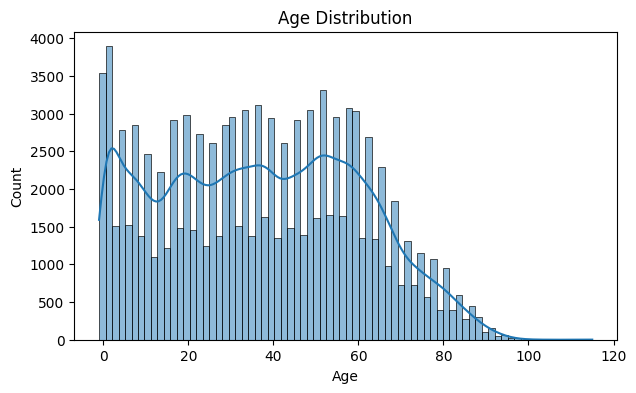

In [ ]:
# ==========================================
# UNIVARIATE ANALYSIS
# ==========================================

# AGE

plt.figure(figsize=(7,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()


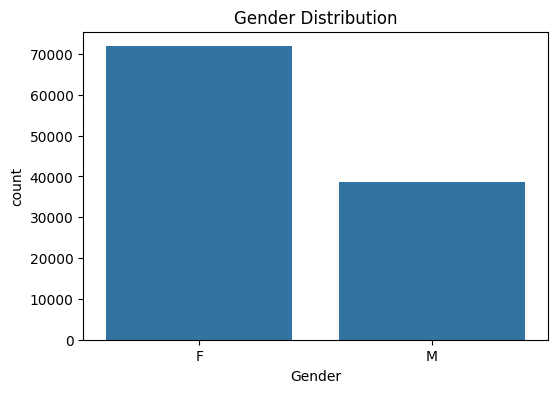

In [ ]:
# GENDER

plt.figure(figsize=(6,4))
sns.countplot(
    x='Gender',
    data=df
)
plt.title("Gender Distribution")
plt.show()

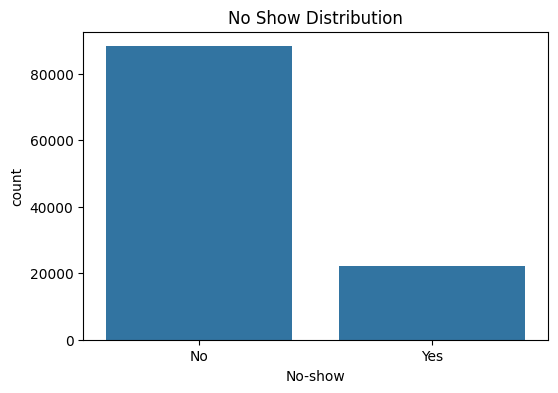

In [ ]:
# NO SHOW

plt.figure(figsize=(6,4))
sns.countplot(
    x='No-show',
    data=df
)
plt.title("No Show Distribution")
plt.show()


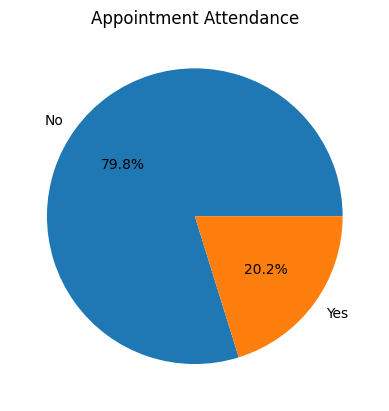

In [ ]:
# PIE CHART
df['No-show'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Appointment Attendance")
plt.ylabel("")
plt.show()

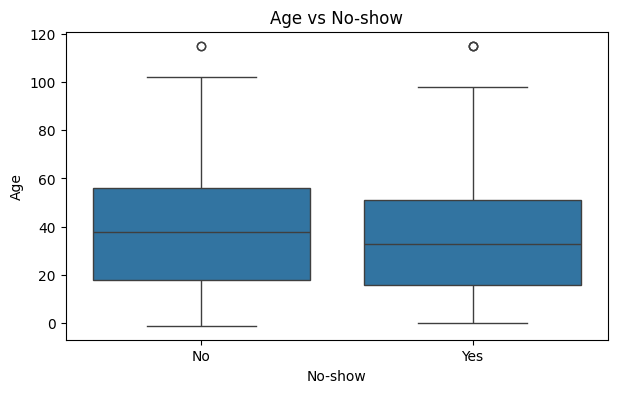

In [ ]:
# ==========================================
# BIVARIATE ANALYSIS
# ==========================================
# AGE VS NO SHOW
plt.figure(figsize=(7,4))
sns.boxplot(
    x='No-show',
    y='Age',
    data=df
)
plt.title("Age vs No-show")
plt.show()


In [ ]:
# GENDER VS NO SHOW

gender_table = pd.crosstab(
    df['Gender'],
    df['No-show']
)

print("\nGENDER VS NO SHOW")
print(gender_table)



GENDER VS NO SHOW
No-show     No    Yes
Gender               
F        57246  14594
M        30962   7725


In [ ]:

# SMS VS NO SHOW

sms_table = pd.crosstab(
    df['SMS_received'],
    df['No-show']
)
print("\nSMS VS NO SHOW")
print(sms_table)



SMS VS NO SHOW
No-show          No    Yes
SMS_received              
0             62510  12535
1             25698   9784


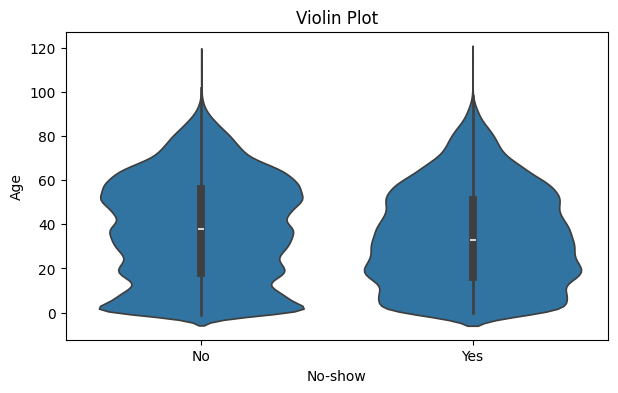

In [ ]:
# ==========================================
# VIOLIN PLOT
# ==========================================

plt.figure(figsize=(7,4))
sns.violinplot(
    x='No-show',
    y='Age',
    data=df
)
plt.title("Violin Plot")
plt.show()


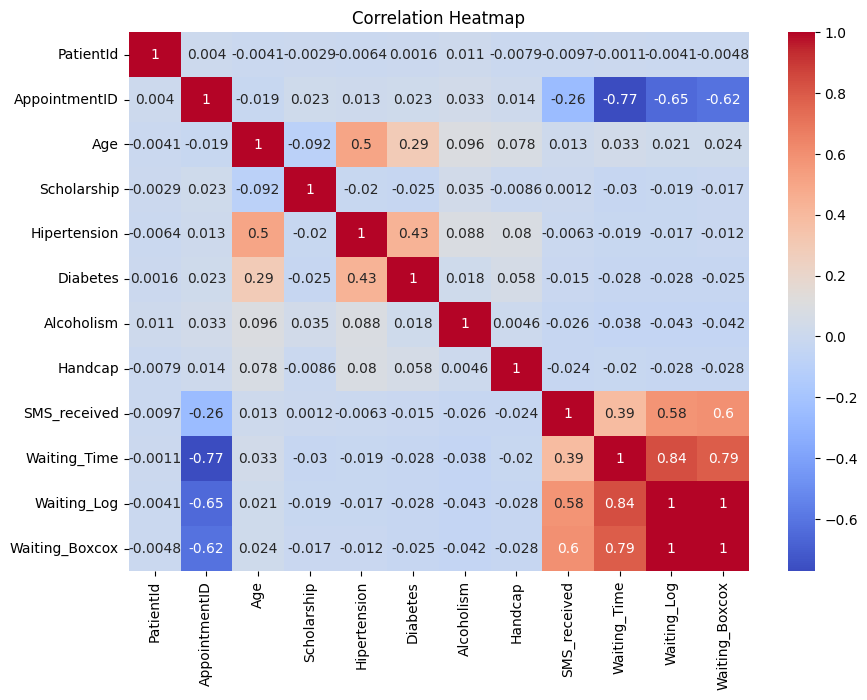

In [ ]:
# ==========================================
# CORRELATION ANALYSIS
# ==========================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


In [ ]:

# ==========================================
# CHI SQUARE TEST
# ==========================================

table = pd.crosstab(
    df['Gender'],
    df['No-show']
)

chi2,p,dof,expected = chi2_contingency(table)

print("\nCHI SQUARE TEST")
print("Chi2:",chi2)
print("P-value:",p)

if p < 0.05:
    print("Significant Relationship Exists")
else:
    print("No Significant Relationship")



CHI SQUARE TEST
Chi2: 1.8534369792394627
P-value: 0.17338418189785987
No Significant Relationship


In [ ]:
# ==========================================
# ANOVA TEST
# ==========================================

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,18,60,120],
    labels=['Young','Adult','Senior']
)

young = df[
    df['Age_Group']=='Young'
]['Waiting_Time']

adult = df[
    df['Age_Group']=='Adult'
]['Waiting_Time']

senior = df[
    df['Age_Group']=='Senior'
]['Waiting_Time']

f,p = f_oneway(
    young,
    adult,
    senior
)
print("\nANOVA TEST")
print("F Statistic:",f)
print("P-value:",p)

if p < 0.05:
    print("Waiting Time differs across Age Groups")
else:
    print("No Significant Difference")



ANOVA TEST
F Statistic: 68.75950630647739
P-value: 1.4364875835974935e-30
Waiting Time differs across Age Groups


In [ ]:
# ==========================================
# BUSINESS INSIGHTS
# ==========================================

print("\n" + "="*50)
print("BUSINESS INSIGHTS")
print("="*50)

print(
    "\nNo-show Percentage"
)

print(
    df['No-show']
    .value_counts(normalize=True)
    *100
)

print(
    "\nAverage Waiting Time:"
)

print(
    round(
        df['Waiting_Time'].mean(),
        2
    ),
    "Days"
)

print(
    "\nTop Neighborhoods"
)

print(
    df['Neighbourhood']
    .value_counts()
    .head(10)
)

print(
    "\nSMS Reminder Effectiveness"
)

print(
    pd.crosstab(
        df['SMS_received'],
        df['No-show'],
        normalize='index'
    )*100
)

print("\nPROJECT COMPLETED SUCCESSFULLY")


BUSINESS INSIGHTS

No-show Percentage
No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

Average Waiting Time:
9.53 Days

Top Neighborhoods
Neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4431
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3132
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
Name: count, dtype: int64

SMS Reminder Effectiveness
No-show              No        Yes
SMS_received                      
0             83.296689  16.703311
1             72.425455  27.574545

PROJECT COMPLETED SUCCESSFULLY
